## HateXplain - 4 OBJECTIVES

### Multi Task Learning

* **Dataset:** HateXplain
* **Task :** Classification

* **Target 1:** Hate speech againt African
* **Target 2:** Hate speech against Women
* **Target 3:** Hate speech against Jewish
* **Target 4:** Hate speech against Homosexual

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import dill
import pickle
import torch
from datasets import load_dataset

/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes
from machinemoo.analysis.metrics import compute_hypervolume_progress

import preprocessing as pp
from scalarization import NLPScalarization

In [4]:
# Setting a seed for reproducibility
from machinemoo.utils.seed_config import set_np_torch_seed
set_np_torch_seed(42)

In [5]:
PREFIX_SAVE_IMAGE = 'images/4_objs'

In [6]:
PREFIX_SAVE_RESULT = '4_objs'

## Dataset and Model

In [7]:
# Get HateXplain Dataset
dataset = load_dataset("Hate-speech-CNERG/hatexplain", trust_remote_code=True)

# Choose BERT model
model_name="bert-base-uncased"

In [8]:
# Use GPU if its available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [9]:
task_config = {
   "African": {"type": "group_hate", "group": "African"},
   "Women": {"type": "group_hate", "group": "Women"},
   "Jewish": {"type": "group_hate", "group": "Jewish"},
   "Homosexual": {"type": "group_hate", "group": "Homosexual"},
}

In [10]:
train_dataloader = pp.get_dataloader(dataset['train'], task_config)

## MOO Modeling and Training

* MOO methods:
    * MOLA
    * Random Weights

In [11]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 500,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}
objectives_names = list(task_config.keys())

# Control optimization output (Default is False):
#   verbose=True -> show optimization progress
#   debug=True   -> show detailed debug information
verbose = False
debug = False

def machine_optimize(method, lb_estimate=0.01):
    w_scalar = NLPScalarization(
        train_dataloader = train_dataloader, 
        device = device, 
        task_names = objectives_names, 
        lower_bound_estimate=lb_estimate
    )
    moopt = moo(w_scalar, verbose=verbose, debug=debug).mo_optimization(method, **opt_params)
    objs = get_objectives(moopt)
    if method == 'mola':
        hypervolume_values = moopt.get_hypervolumes()
    else:
        hypervolume_values = compute_hypervolume_progress(objs)
    if lb_estimate == 'lipschitz':
        method = f'{method}_grad'
    results[method] = {
                    "moopt": moopt,
                    "objectives": objs,
                    "models": get_models(moopt),
                    "hypervolume": hypervolume_values
                }

In [12]:
def plot_frontier(method, color="#d73027"):
    title="Loss Trade-offs in Multi-Group Hate Speech Detection"
    plot_pareto(methods={method: results[method]['objectives']},
                labels=objectives_names, 
                title=title,
                color=color,
                fontsize=25,
                figsize=(10,7),
                save_path=f'{PREFIX_SAVE_IMAGE}_{method}.pdf'
                )

### MOLA

In [14]:
method = 'mola'
machine_optimize(method=method)

load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


...

load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/pandas/plotting/_matplotlib/misc.py:422: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")
<string>:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


<Figure size 1000x700 with 0 Axes>

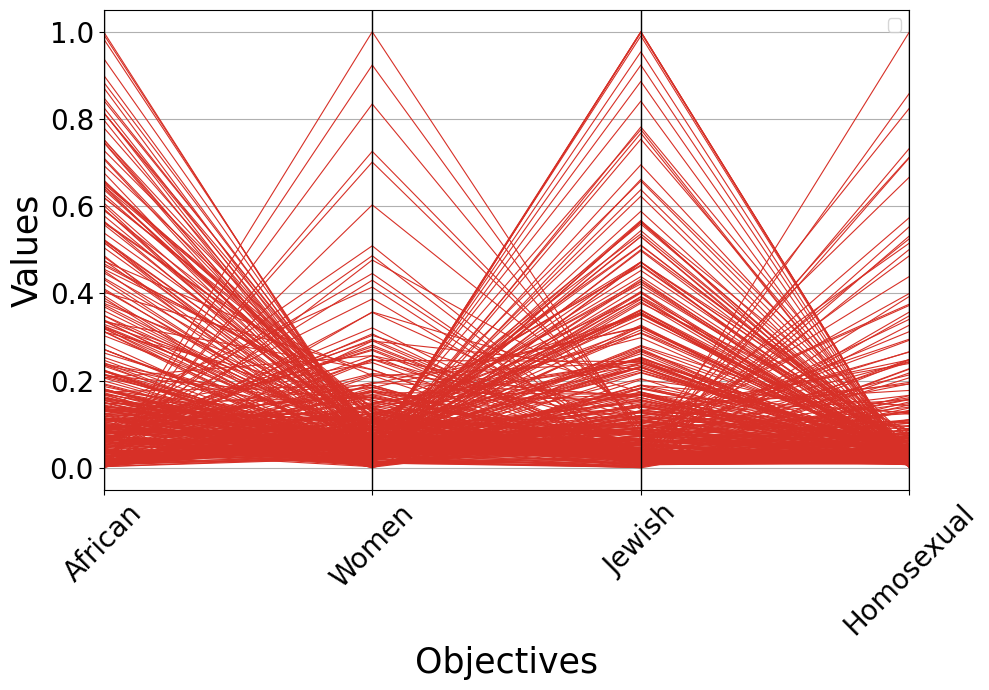

In [18]:
plot_frontier('mola', color='#d73027')

### MOLA with gradient

In [19]:
method = 'mola'
machine_optimize(method=method, lb_estimate='lipschitz')

load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


...

load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


load_solution=False and check results.termination_condition and
results.found_feasible_solution() before loading a solution.


/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/pandas/plotting/_matplotlib/misc.py:422: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")
<string>:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


<Figure size 1000x700 with 0 Axes>

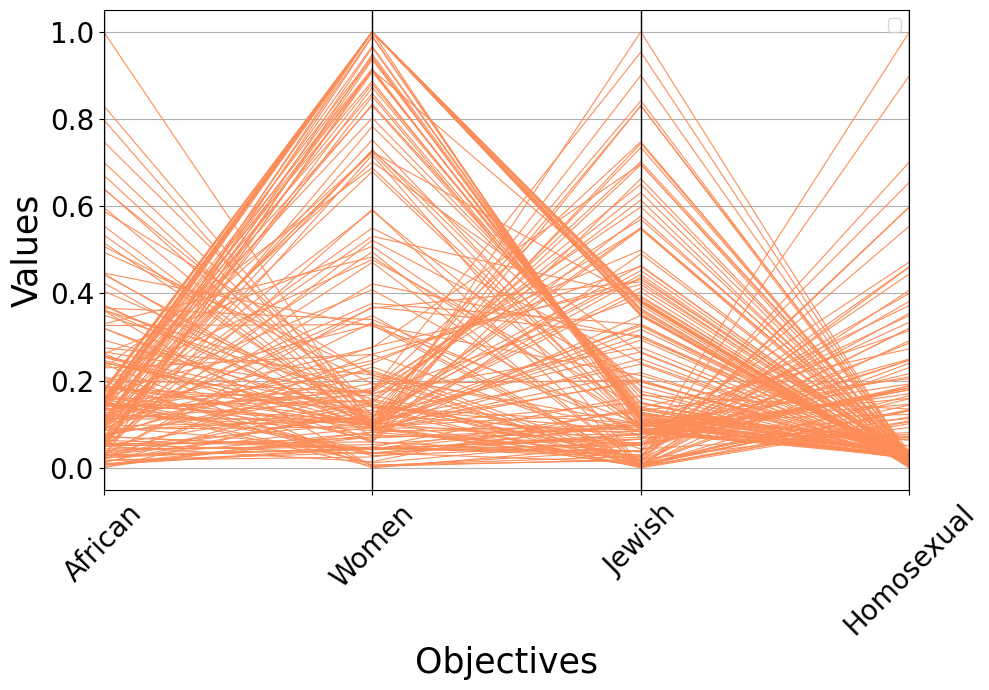

In [19]:
plot_frontier(f'mola_grad', color='#fc8d59')

### Random Weight

In [ ]:
method = 'random_weights'
machine_optimize(method=method)

### Non-dominated Solutions Analysis

In [23]:
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
rw_solutions = results['random_weight']['objectives']
nd_indices = NonDominatedSorting().do(rw_solutions, only_non_dominated_front=True)
rw_non_dominated_solutions = rw_solutions[nd_indices]

print(f'Number of non-dominated solutions with MOLA          : {len(results['mola']['objectives'])}')
print(f'Number of non-dominated solutions with MOLA GRAD     : {len(results['mola_grad']['objectives'])}')
print(f'Number of non-dominated solutions with RANDOM WEIGHT : {len(rw_non_dominated_solutions)}')

Number of non-dominated solutions with MOLA          : 380
Number of non-dominated solutions with MOLA GRAD     : 175
Number of non-dominated solutions with RANDOM WEIGHT : 214


## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/pandas/plotting/_matplotlib/misc.py:422: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")
<string>:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/pandas/plotting/_matplotlib/misc.py:422: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")
<string>:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/hom

<Figure size 3000x700 with 0 Axes>

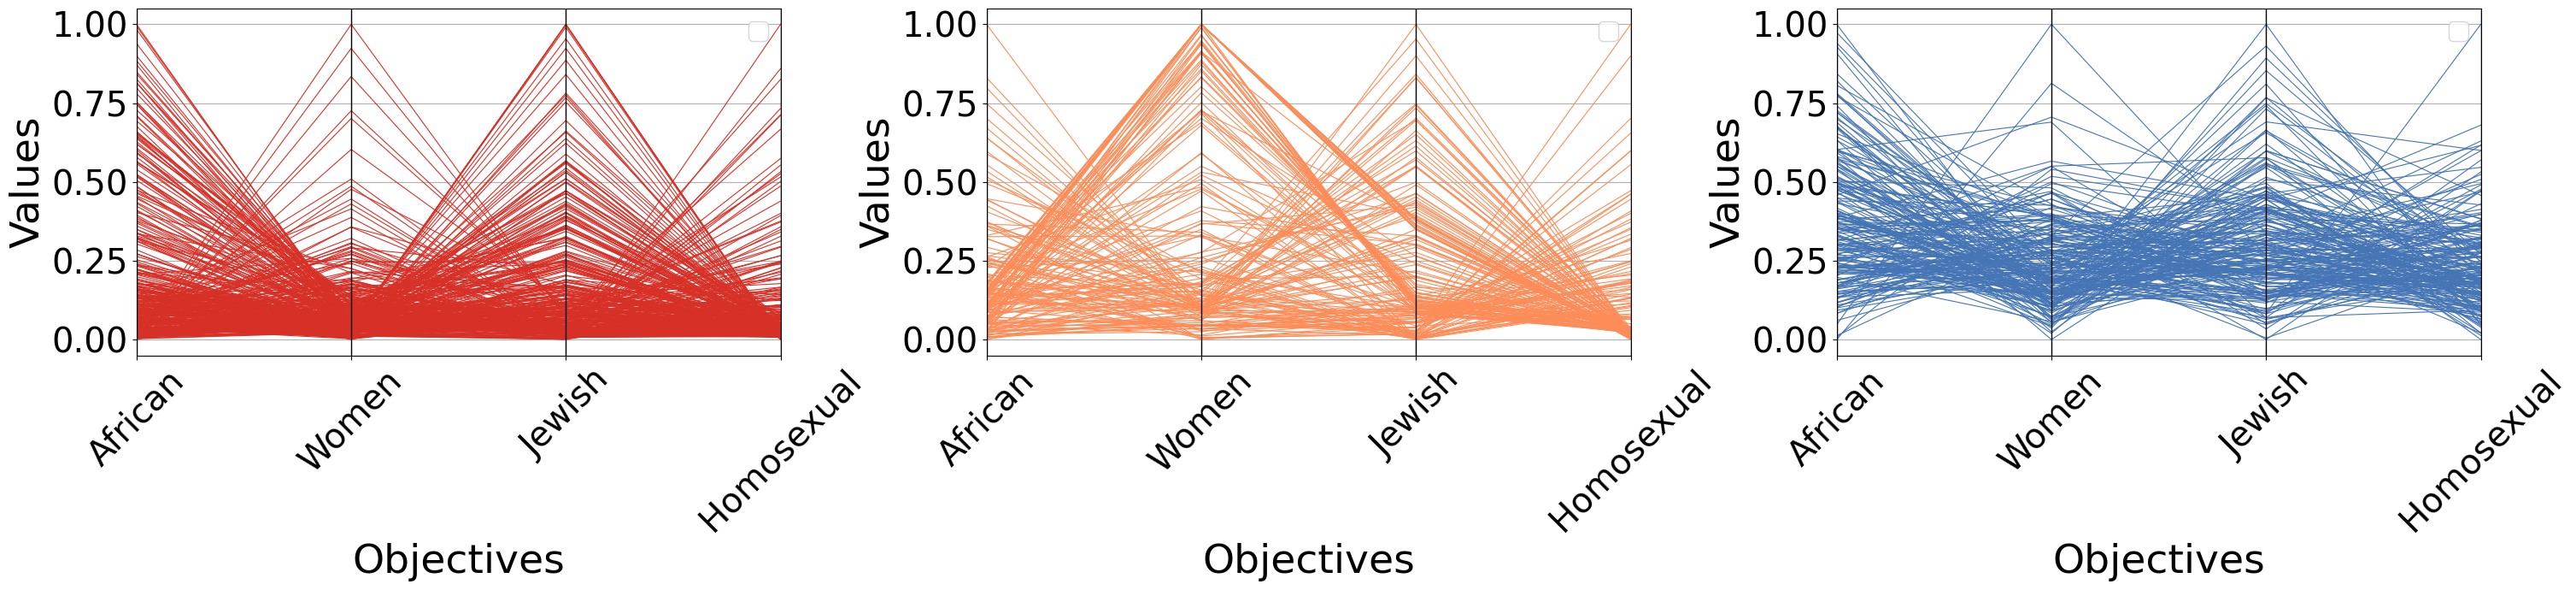

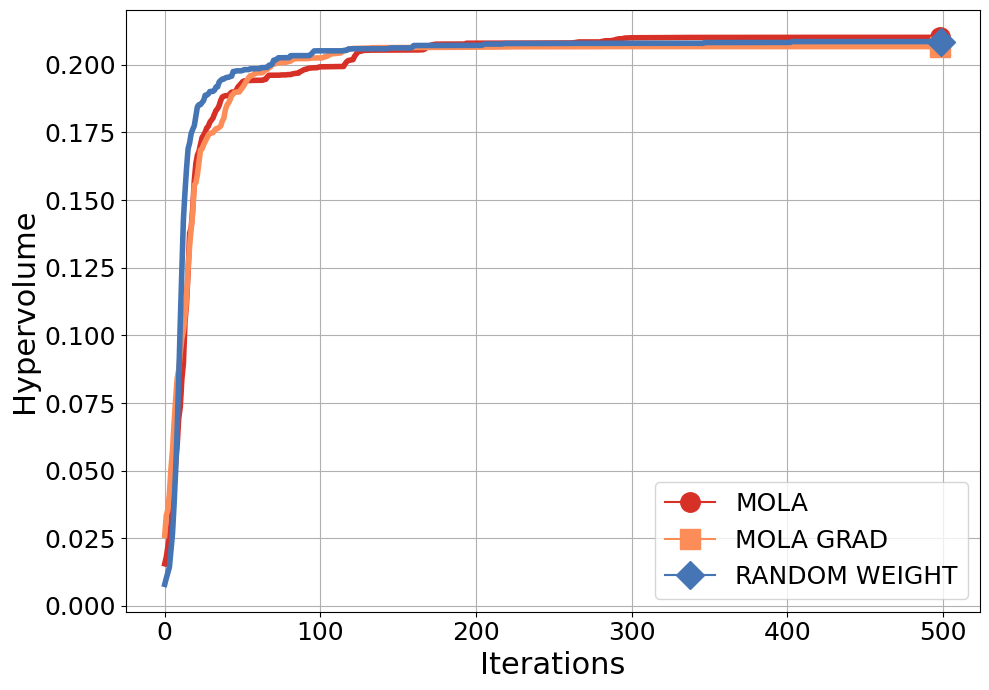

In [17]:
pareto_dict = {
        method: res['objectives']
        for method, res in results.items()
        if 'objectives' in res and method != 'random_weight'
    }

pareto_dict['random_weights'] = rw_non_dominated_solutions

hypervolumes_dict = {
        method: res['hypervolume']
        for method, res in results.items()
        if 'hypervolume' in res
    }

plot_pareto(methods=pareto_dict,
            labels=objectives_names, 
            #title='Comparative Pareto Frontiers Across MOO Methods',
            #subset=equal.objs,
            fontsize=34,
            figsize=(10,7),
            save_path=f'{PREFIX_SAVE_IMAGE}_methods.pdf'
            )

plot_multiple_hypervolumes(methods_hv=hypervolumes_dict, save_path=f'{PREFIX_SAVE_IMAGE}_hypervolume.pdf')

In [13]:
# save results
#with open(f"results_{PREFIX_SAVE_RESULT}.pkl", "wb") as f:
#    dill.dump(results, f)

# get saved results
with open(f"results_{PREFIX_SAVE_RESULT}.pkl", "rb") as f:
    results = pickle.load(f)

## Evaluation and Best Solution Criteria - Analysis with MOLA

In [28]:
from machinemoo.analysis.decision import topsis_model_selection

In [ ]:
import torch
import torch.nn as nn
import numpy as np

def compute_val_losses(
    models,
    val_loader,
    task_names,
    device
):
    """
    Computes the validation loss matrix.
    
    Args:
        models: list of trained models
        val_loader: DataLoader for the validation set
        objectives: list of loss functions (one per objective)

    Returns:
        losses: tensor with shape (n_models, n_objectives)
    """
    n_obj = len(task_names)
    #objs = torch.zeros((n_models, n_obj), dtype=torch.float32)

    val_losses = []
    for model in models:
        total_batches = 0
        eval_losses = np.zeros(n_obj)
        model.eval()
        criterion = nn.CrossEntropyLoss()
        with torch.no_grad():
            for batch in val_loader:
                embeddings = batch["embedding"].to(device)
                logits_dict = model(embeddings)
                for i, task in enumerate(task_names):
                    labels = batch[task].to(device)
                    loss = criterion(logits_dict[task], labels)
                    eval_losses[i] += loss.item()
                total_batches += 1
        # eval_losses /= len(self.train_dataloader)
        eval_losses /= total_batches
        val_losses.append(eval_losses)

    return np.array(val_losses)

In [15]:
val_dataloader = pp.get_dataloader(dataset['validation'], task_config)

In [26]:
val_losses = compute_val_losses(
    models=results['mola']['models'],
    val_loader=val_dataloader,
    task_names=task_config,
    device=device
)

In [37]:
topsis_res = topsis_model_selection(val_losses)
#print(topsis_res[0])

In [38]:
topsis_res

(    Model  TOPSIS Score  Original Index  Rank
 0    M361      0.986996             361     1
 1    M375      0.985744             375     2
 2    M366      0.972340             366     3
 3    M117      0.968955             117     4
 4    M275      0.968947             275     5
 ..    ...           ...             ...   ...
 375    M5      0.514986               5   376
 376  M188      0.469329             188   377
 377  M344      0.457291             344   378
 378  M261      0.383242             261   379
 379  M219      0.371101             219   380
 
 [380 rows x 4 columns],
 361,
 'M361',
 array([0.02466719, 0.00648129, 0.00148328, 0.005345  ]))

/home/lineccsa/mestrado/machinemoo/venv_moo/lib/python3.12/site-packages/pandas/plotting/_matplotlib/misc.py:422: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right")


<Figure size 1000x700 with 0 Axes>

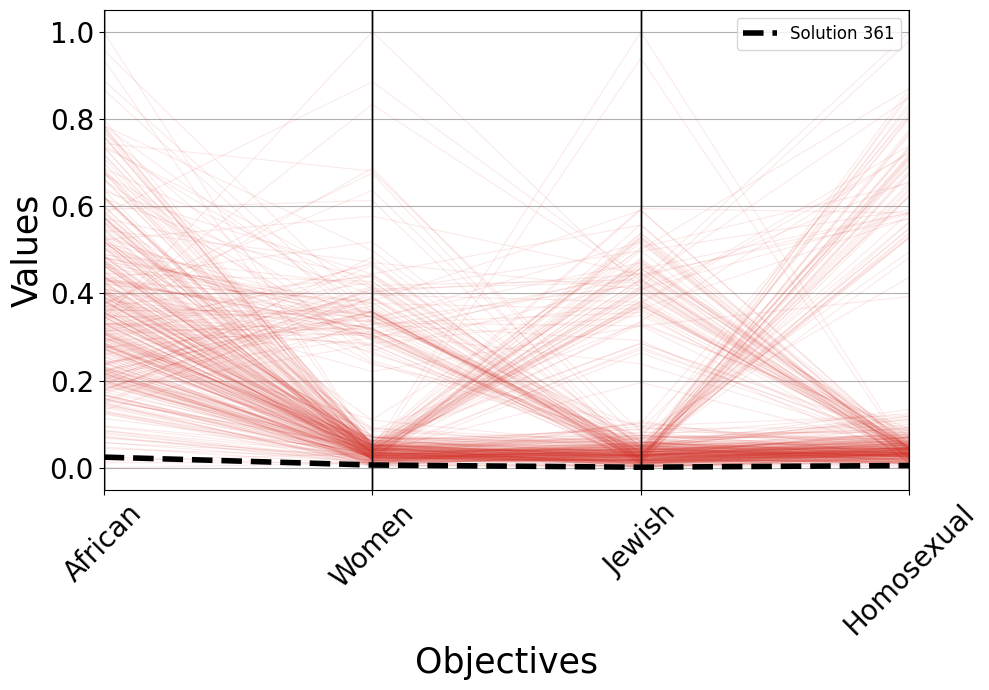

In [41]:
title=""
plot_pareto(methods={'mola': val_losses},
            labels=objectives_names, 
            title=title,
            fontsize=25,
            figsize=(10,7),
            subset=topsis_res[3],
            subset_label=f'Solution {topsis_res[1]}',
            save_path=f'{PREFIX_SAVE_IMAGE}_mola_topsis.pdf',
            alpha=0.1,
            s_factor=5,
            )

In [ ]:
topsis_res = topsis_model_selection(val_losses, weights=[0.6, 0.2, 0.1, 0.1])
#print(topsis_res[0])

In [ ]:
plot_pareto(methods={'mola': val_losses},
            labels=objectives_names, 
            #title=title,
            fontsize=25,
            figsize=(10,7),
            subset=topsis_res[3],
            subset_label=f'Solution {topsis_res[1]}',
            save_path=f'{PREFIX_SAVE_IMAGE}_mola_topsis_weighted.pdf',
            alpha=0.15,
            s_factor=5,
            color='grey',
            subset_color="#a50026"
            )

In [ ]:
# Get best model
val_result = {}
for j, task in enumerate(objectives_names):
    best_model_idx = int(val_losses[:, j].argmin())
    best_loss = float(val_losses[:, j].min())
    val_result[task] = {
        "best_model": best_model_idx,
        "best_loss": best_loss,
    }

In [46]:
import pandas as pd
df = pd.DataFrame(val_result).T  # .T = transpose, tasks viram índice
print(df)


            best_model  best_loss
African          375.0        0.0
Women            357.0        0.0
Jewish           323.0        0.0
Homosexual       143.0        0.0
